Yuliia Chernysheva  
April 18, 2026  
CIS 2266

# **Titanic Data Analysis Project (Part1)**

*On April 15, 1912, the largest passenger liner ever made collided with an iceberg during her maiden voyage. When the Titanic sank it killed **1502 out of 2224** passengers and crew. This sensational tragedy shocked the international community and led to better safety regulations for ships. One of the reasons that the shipwreck resulted in such loss of life was that there were not enough lifeboats for the passengers and crew. Although there was some element of luck involved in surviving the sinking, some groups of people were more likely to survive than others.*

**Research Objectives**

In this project, we utilize Python and the Titanic dataset to perform an **Exploratory Data Analysis (EDA)** and answer the following key questions:

1. **Vulnerability & Class:** What is the probability of survival for a child (10 years old or younger) traveling in Third Class?
2. **Economic Overview:** What was the average fare paid by passengers to board the ship?
3. **Price Disparity:** What were the minimum and maximum fares paid across different passenger classes?

# **Exploratory Data Analysis**

Before proceeding to visual analysis and calculations, a technical inspection of the raw data is required. This step ensures a clear understanding of the dataset's structure, identifies missing values, and reveals the statistical ranges of the variables.

## *Initial Data Inspection*

The analysis begins with a preview of the first few rows to identify the information provided in each column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Constants for the project colors
COLOR_LOST = '#E63946'
COLOR_SURVIVED = '#0077B6'
COLOR_TEXT = '#2F2F2F'
COLOR_GRID = '#E0E0E0'

# Load Data
df = pd.read_csv('titanic.csv')
display(df.head())

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


## *Data Structure and Features*

To ensure accurate calculations, it is necessary to verify data types and list all available features in the dataset.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Survived                 887 non-null    int64  
 1   Pclass                   887 non-null    int64  
 2   Name                     887 non-null    object 
 3   Sex                      887 non-null    object 
 4   Age                      887 non-null    float64
 5   Siblings/Spouses Aboard  887 non-null    int64  
 6   Parents/Children Aboard  887 non-null    int64  
 7   Fare                     887 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 55.6+ KB


In [3]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

### **1.1. Data Dictionary**

| Variable | Definition | Key / Notes |
| :--- | :--- | :--- |
| **Survived** | Survival status | 0 = No, 1 = Yes |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Name** | Full passenger name | |
| **Sex** | Gender | Male, Female |
| **Age** | Age in years | |
| **Siblings/Spouses** | # of siblings or spouses aboard | Sibling: brother, sister, etc.<br> Spouse: husband, wife |
| **Parents/Children** | # of parents or children aboard | Parent: mother, father<br>Child: daughter, son, etc. |
| **Fare** | Passenger fare | Price in British Pounds |

## *Statistical Summary*

The following summary provides a quick overview of numerical features, showing the mean, standard deviation, and range for variables such as **Age** and **Fare**.

In [4]:
display(df.describe().round(2))

,Survived,Pclass,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
count,887.00,887.00,887.00,887.00,887.00,887.00
mean,0.39,2.31,29.47,0.53,0.38,32.31
std,0.49,0.84,14.12,1.10,0.81,49.78
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.25,0.00,0.00,7.92
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.14
max,1.00,3.00,80.00,8.00,6.00,512.33


## *Data Integrity: Missing Values Check*

Checking for missing data is essential, as gaps in the **Age** or **Fare** columns could impact the accuracy of the final results.

In [5]:
df.isnull().sum()

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64

## *Technical Summary*

* **Data Completeness:** The initial inspection indicates that key columns, such as Survived, Pclass, Age, and Fare, contain complete data, allowing for analysis without additional cleaning.
* **Feature Diversity:** The dataset includes a mix of categorical features (Class, Sex) and continuous numerical values (Age, Fare), enabling a multi-dimensional study of survival factors.
* **Economic Variance:** The statistical summary reveals a massive spread in ticket prices, ranging from £0 to over £500, reflecting the clear social stratification among passengers.

# **Visual Analysis**

## **Age and Fare Correlation**

To establish a holistic view of the passengers, this scatterplot examines the relationship between **Age** and **Ticket Fare**, with color indicating **Survival**. This visualization helps identify whether wealth (fare) and youth (age) provided a combined advantage during the disaster.

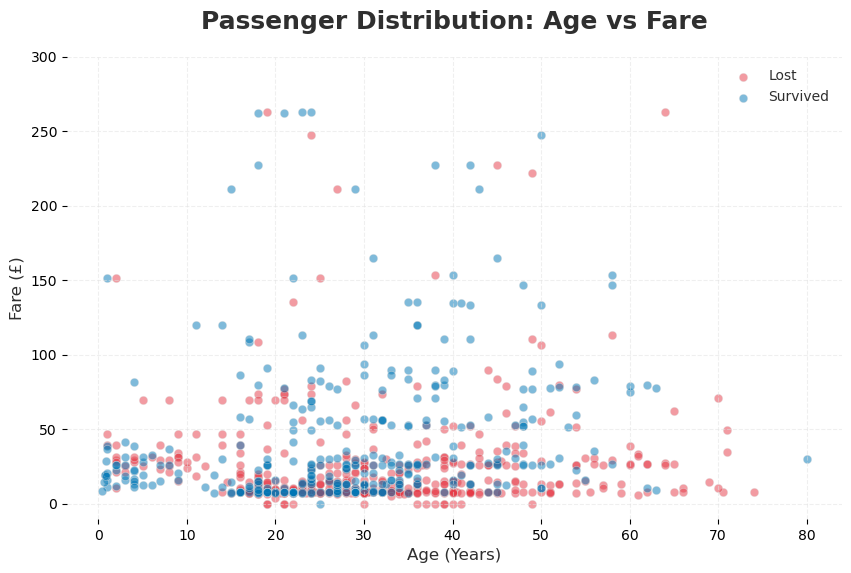

In [6]:
# Plotting the data
plt.figure(figsize=(10,6))

plt.scatter(df[df['Survived'] == 0]['Age'],
            df[df['Survived'] == 0]['Fare'],             
            color=COLOR_LOST, alpha=0.5, label='Lost', 
            edgecolors=COLOR_GRID, linewidth=0.5)
plt.scatter(df[df['Survived'] == 1]['Age'],
            df[df['Survived'] == 1]['Fare'],             
            color=COLOR_SURVIVED, alpha=0.5, label='Survived', 
            edgecolors=COLOR_GRID, linewidth=0.5)

plt.title('Passenger Distribution: Age vs Fare', color=COLOR_TEXT,
          fontweight='bold', fontsize=18, pad=20)
plt.xlabel('Age (Years)', color=COLOR_TEXT, fontsize=12)
plt.ylabel('Fare (£)', color=COLOR_TEXT, fontsize=12)

plt.legend(frameon=False, labelcolor=COLOR_TEXT, loc='upper right')
plt.grid(True, color=COLOR_GRID, alpha=0.5, linestyle='--')
plt.box(False)
plt.ylim(-10, 300)
plt.show()

**Analysis Summary:**

* **The Wealth Concentration:** A dense cluster is visible at lower fare levels (below **£50**), representing the majority of the passengers. Within this cluster, red points (those who were lost) are heavily concentrated across all age groups.
* **Luxury Advantage:** In the upper portion of the graph (higher fares), blue points (survivors) become much more frequent, indicating that higher ticket prices often correlated with better survival chances.
* **Vulnerable Age Groups:** Children (left side of the plot) show a mix of outcomes, but there is a visible survival trend for the youngest passengers, which will be analyzed specifically in the following section.

## **Demographic Overview: Age Distribution**

Understanding the age of the passengers is crucial, especially since maritime tradition often prioritizes "women and children first." Before calculating specific survival probabilities for younger passengers, the following histogram visualizes the overall age demographics and survival status of the Titanic passengers.

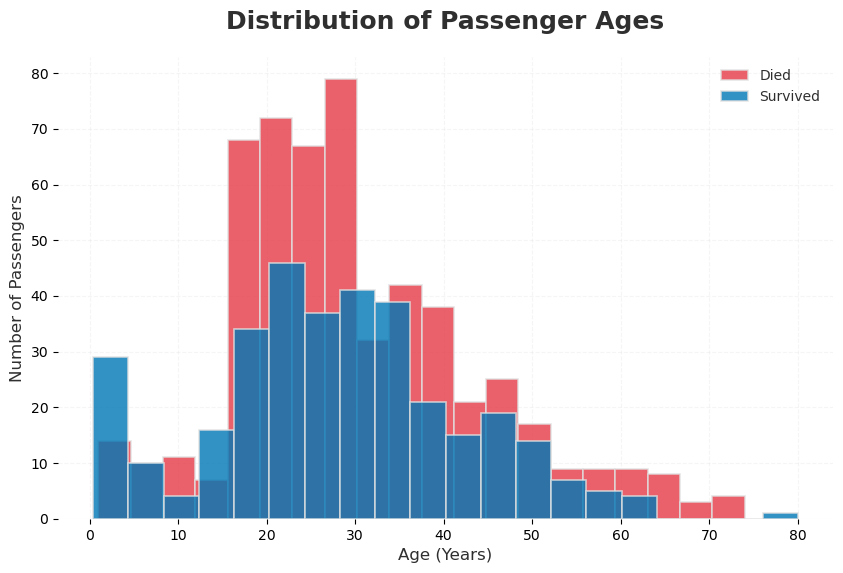

In [7]:
plt.figure(figsize=(10,6))

# Splitting the Data
ages_survived = df[df['Survived'] == 1]['Age'].dropna()
ages_died = df[df['Survived'] == 0]['Age'].dropna()    

plt.hist(ages_died, bins=20, color=COLOR_LOST, alpha=0.8,
         label='Died', edgecolor=COLOR_GRID, linewidth=1.2, zorder=3)
plt.hist(ages_survived, bins=20, color=COLOR_SURVIVED, alpha=0.8,
        label='Survived', edgecolor=COLOR_GRID, linewidth=1.2, zorder=3)

plt.title('Distribution of Passenger Ages', color=COLOR_TEXT, 
          fontweight='bold', fontsize=18, pad=20)
plt.xlabel('Age (Years)', color=COLOR_TEXT, fontsize=12)
plt.ylabel('Number of Passengers', color=COLOR_TEXT,  fontsize=12)

plt.legend(frameon=False, labelcolor=COLOR_TEXT)
plt.grid(True, color=COLOR_GRID, linestyle='--', alpha=0.3, zorder=0)
plt.box(False)

plt.show()

**Analysis Summary:**

* **Children's Advantage:** There is a distinct "survival bump" for children under 10. In this segment, the proportion of survivors (blue) is significantly higher relative to deaths compared to any other age group.
* **Adult Mortality:** The 18–35 age group represents the largest demographic but also faces the highest mortality rate, consistent with the policy of prioritizing vulnerable passengers.
* **Logical Transition:** This visual evidence confirms that age was a significant factor. However, the question remains: did this advantage hold true even for the most disadvantaged group - the **3rd Class**?

# Research Question 1: Children in 3rd Class
## **Question:** What is the probability that a child who is in third class and is 10 years old or younger survives?

The previous demographic overview showed that children generally had a higher chance of survival. However, it is vital to investigate if this "priority" remained effective for those in the lower decks. We are calculating the survival probability for passengers who meet two specific criteria:

1. They were in the **3rd Class**.
2. They were **10 years old or younger**.

>> Total children (<=10) in 3rd class: 53
>> Survived of them: 22
>> Survival probability for this group: 41.51%

>> P.S. Overall survival rate in 1st Class: 63.0%



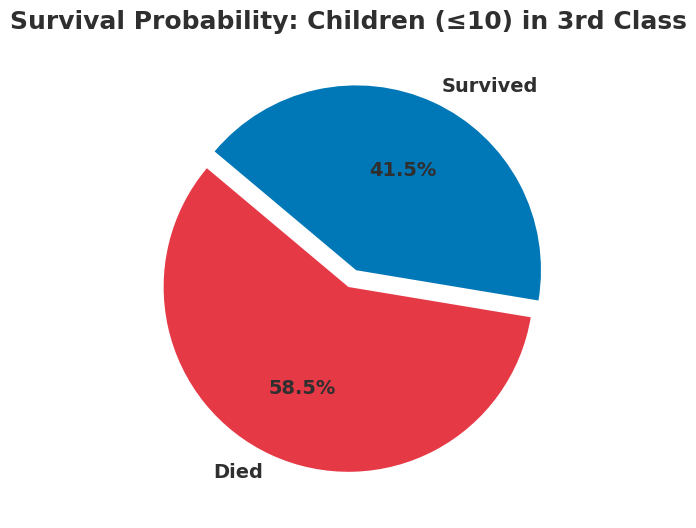

In [8]:
# Survival probability for a child (<= 10 years old) in 3rd Class
# Filter the data based on two conditions: class and age
child_3cl_df = df[(df['Pclass'] == 3) & (df['Age'] <= 10)]

total_child_3cl = len(child_3cl_df)
survived_child_3cl = child_3cl_df['Survived'].sum()

#  Probability that a child who is in third class and is 10 years old or younger survives
prob_child_3cl = survived_child_3cl / total_child_3cl

print(f">> Total children (<=10) in 3rd class: {total_child_3cl}")
print(f">> Survived of them: {survived_child_3cl}")
print(f">> Survival probability for this group: {prob_child_3cl:.2%}")

first_class = df[df['Pclass'] == 1]
prob_1cl = first_class['Survived'].mean()
print(f"\n>> P.S. Overall survival rate in 1st Class: {prob_1cl:.1%}\n")

# Visualization: Pie chart 
chart_colors = [COLOR_LOST, COLOR_SURVIVED]
labels = ['Died', 'Survived']
sizes = [total_child_3cl - survived_child_3cl, survived_child_3cl]
explode = (0, 0.1)

plt.figure(figsize=(10,6))
plt.pie(sizes, explode=explode, labels=labels, colors=chart_colors,
        autopct='%1.1f%%', shadow=False, startangle=140,
        textprops={'fontsize': 14, 'fontweight': 'bold', 'color': COLOR_TEXT})

plt.title('Survival Probability: Children (≤10) in 3rd Class', color=COLOR_TEXT, fontweight='bold', fontsize=18, pad=20)

plt.show()

**Analysis Results:**

* **Survival Odds:** For a child in the 3rd class, the probability of survival was **41.5%**.
* **The Class Gap:** Comparing this to the **63.0%** survival rate of 1st-class passengers (regardless of age), it becomes clear that being a child did not fully compensate for the disadvantage of being in 3rd class.
* **Visual Insight:** The pie chart illustrates that more than half of the children in 3rd class perished. This emphasizes that cabin location and deck access were often more critical than age during the rescue efforts.

# **Financial Analysis: Fare Distribution**

Ticket prices on the Titanic were not just a cost, but a reflection of the stark social stratification on board. Before calculating the specific averages and ranges requested in the objectives, this visualization shows how fares were distributed across all passengers.

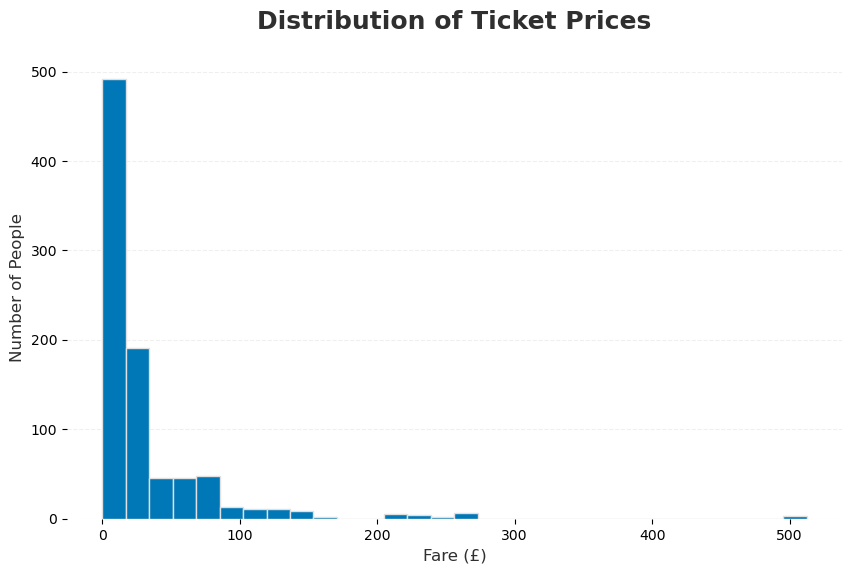

In [9]:
plt.figure(figsize = (10,6))

ax = df['Fare'].plot(kind='hist', bins=30, color=COLOR_SURVIVED,
                     edgecolor=COLOR_GRID, linewidth=1, zorder=3)

plt.title('Distribution of Ticket Prices', color=COLOR_TEXT, 
          fontweight='bold', fontsize=18, pad=20)
plt.xlabel('Fare (£)', color=COLOR_TEXT, fontsize=12)
plt.ylabel('Number of People', color=COLOR_TEXT, fontsize=12)

plt.grid(False)
plt.grid(axis='y', color=COLOR_GRID, linestyle='--', alpha=0.5, zorder=0)
plt.box(False)

plt.show()

**Analysis Summary:**

* **Mass Market:** The vast majority of passengers paid less than **£50** for their journey, representing the 3rd and 2nd class travelers.
* **Luxury Outliers:** A "long tail" is visible in the data, where a small number of elite passengers paid significantly higher fares, sometimes exceeding **£500**.
* **Transition to Stats:** This wide spread explains why a single average fare might be misleading. It highlights the importance of analyzing **minimum and maximum** prices specifically for each class to get an accurate financial picture.

# **Answers to Research Questions 2 & 3**

**Question2: How much did people pay to be on the ship (average)?**

**Question3: What were the lowest and highest fares paid by passenger-class?**

The concluding part of the analysis involves calculating the average fare and identifying the price extremes for each ticket class. This provides a clear quantitative view of the economic diversity among the passengers.

To visualize the financial gap, a boxplot is utilized. This tool is ideal for showing the median price, the overall range, and identifying outliers (those extremely expensive tickets that sit far outside the norm for each class).

>> Overall Average Fare: £32.31

>> Fare Ranges by Passenger Class:
        min     max
Pclass             
1       0.0  512.33
2       0.0   73.50
3       0.0   69.55

>> Number of passengers with free tickets: 15



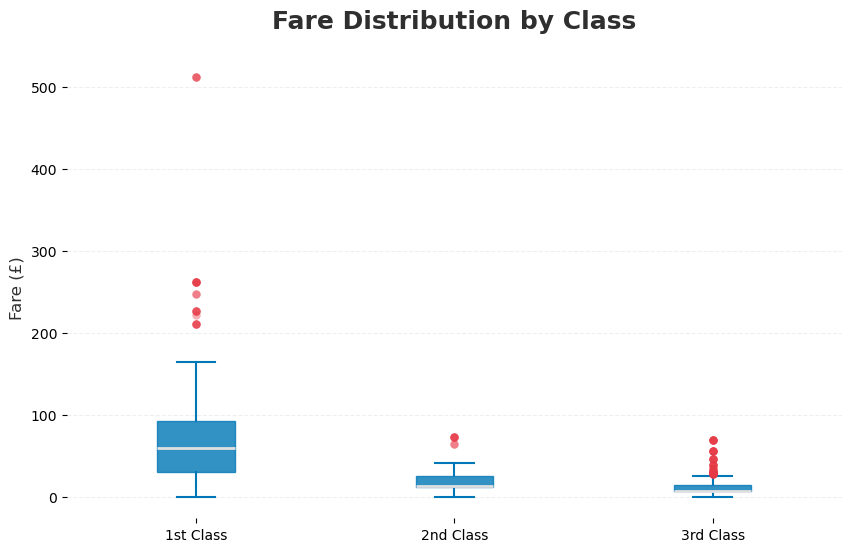

In [10]:
# Calculating Average, Min, and Max Fares
avg_fare = df['Fare'].mean()
fare_stats = df.groupby('Pclass')['Fare'].agg(['min', 'max'])

print(f">> Overall Average Fare: £{avg_fare:.2f}")
print("\n>> Fare Ranges by Passenger Class:")
print(fare_stats.round(2))

free_tickets = df[df['Fare'] == 0]
print(f"\n>> Number of passengers with free tickets: {len(free_tickets)}\n")

# Visualization: Boxplot
plt.figure(figsize=(10, 6))
# Preparing data for each class
class_data = [df[df['Pclass'] == i]['Fare'] for i in [1, 2, 3]]

# Creating the boxplot
bp = plt.boxplot(class_data, patch_artist=True, 
                 tick_labels=['1st Class', '2nd Class', '3rd Class'],
                 medianprops={'color': COLOR_GRID, 'linewidth': 2},
                 boxprops={'facecolor': COLOR_SURVIVED, 'edgecolor': COLOR_SURVIVED, 
                           'alpha': 0.8},
                 whiskerprops={'color': COLOR_SURVIVED, 'linewidth': 1.5},
                 capprops={'color': COLOR_SURVIVED, 'linewidth': 1.5},
                 flierprops={'marker': 'o', 'markerfacecolor': COLOR_LOST, 
                             'markeredgecolor': 'none', 'alpha': 0.4})

plt.title('Fare Distribution by Class', color=COLOR_TEXT, 
          fontweight='bold', fontsize=18, pad=20)
plt.ylabel('Fare (£)', color=COLOR_TEXT, fontsize=12)
plt.grid(axis='y', color=COLOR_GRID, linestyle='--', alpha=0.5)
plt.box(False)

plt.show()

**Analysis of Results**

* **Average Fare:** The overall average ticket price across all passengers was **£32.31**.
* **Wealth Gap:** The 1st Class box is much taller, indicating that prices varied significantly (ranging from complementary tickets to luxury suites).
* **The "Cheaper" Classes:** 2nd and 3rd classes have very compact boxes, meaning almost all passengers in these groups paid a similar, low price.
* **Outliers (Red Dots):** The red dots above the 1st Class box represent ultra-wealthy outliers who paid record-breaking prices (up to **£512.33**) for their accommodations.
* **Zero Fares:** In all classes, the bottom "whisker" of the boxplot touches zero. This confirms the presence of passengers traveling on complementary tickets, such as the shipyard's Guarantee Group, musicians, and repositioned staff.

# **Conclusion**

The analysis confirms that survival on the Titanic was not merely a matter of chance but was deeply tied to social and economic factors. While age provided a survival advantage to children in general, the harsh reality of the 3rd-class statistics shows that cabin location often outweighed age as a factor for rescue.